In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("traffic.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [3]:
df['date'] = pd.to_datetime(df['date'])

df = df.dropna()

df = df.sort_values(by='date')

In [4]:
df['session_id'] = df['linkid']

df['user_id'] = df['city'] + "_" + df['country']

In [5]:
sessions = df['session_id'].nunique()

In [6]:
users = df['user_id'].nunique()

In [7]:
session_counts = df.groupby('session_id').size()
bounce_sessions = session_counts[session_counts == 1].count()

bounce_rate = (bounce_sessions / sessions) * 100

In [8]:
session_time = df.groupby('session_id')['date'].agg(['min','max'])
session_time['duration'] = (session_time['max'] - session_time['min']).dt.seconds

avg_session_duration = session_time['duration'].mean()

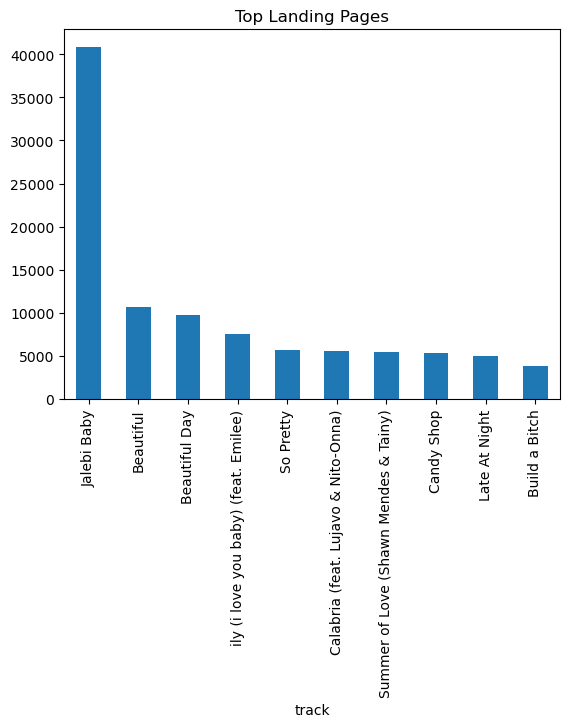

In [9]:
top_tracks = df['track'].value_counts().head(10)

top_tracks.plot(kind='bar', title="Top Landing Pages")
plt.show()

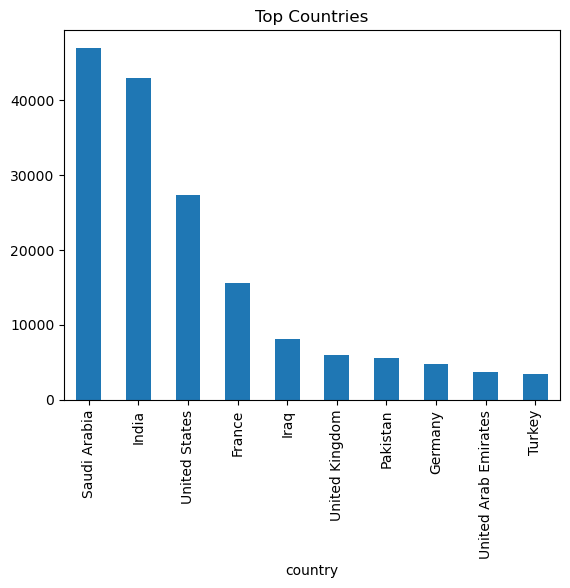

In [10]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.show()

In [11]:
journey = df.groupby('session_id')['track'].apply(list)
journey.head()

session_id
006af6a0-1f0d-4b0c-93bf-756af9071c06    [dear katara, dear katara, dear katara, dear k...
00759b81-3f04-4a61-b934-f8fb3185f4a0    [Primero Yo, Primero Yo, Primero Yo, Primero Y...
00829040-ee01-4409-966d-d67c7965144a    [Beautiful Soul, Beautiful Soul, Beautiful Sou...
009193ee-c3df-4efa-88f2-feb37c0bfdf2    [Ain't It Fun, Ain't It Fun, Ain't It Fun, Ain...
00de7566-f014-4d20-8616-82e4dea45b88    [Wiggle feat Snoop Dogg, Wiggle feat Snoop Dog...
Name: track, dtype: object

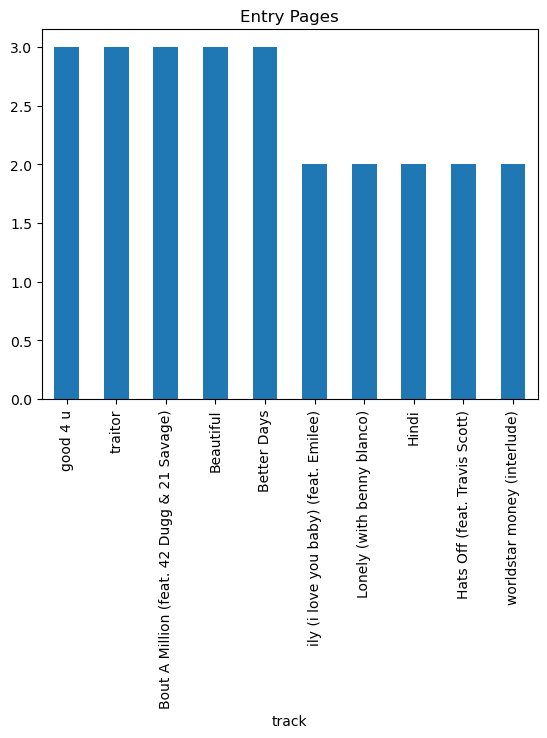

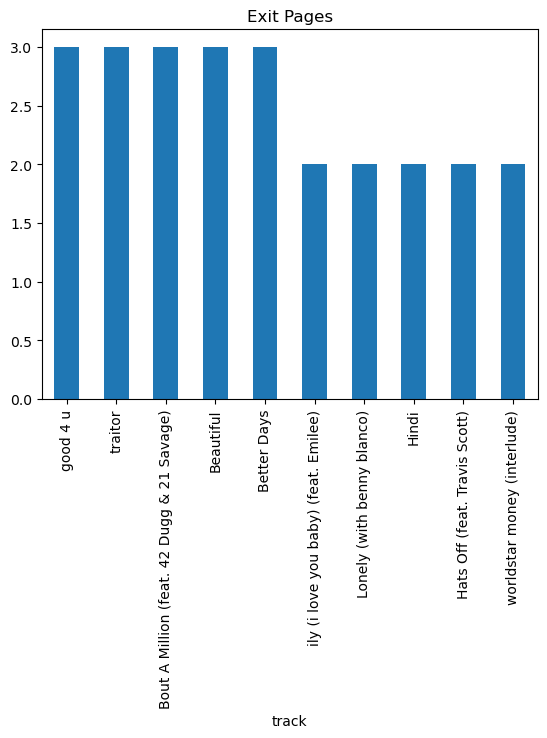

In [12]:
entry_pages = df.groupby('session_id').first()['track']
exit_pages = df.groupby('session_id').last()['track']

entry_pages.value_counts().head(10).plot(kind='bar', title="Entry Pages")
plt.show()

exit_pages.value_counts().head(10).plot(kind='bar', title="Exit Pages")
plt.show()

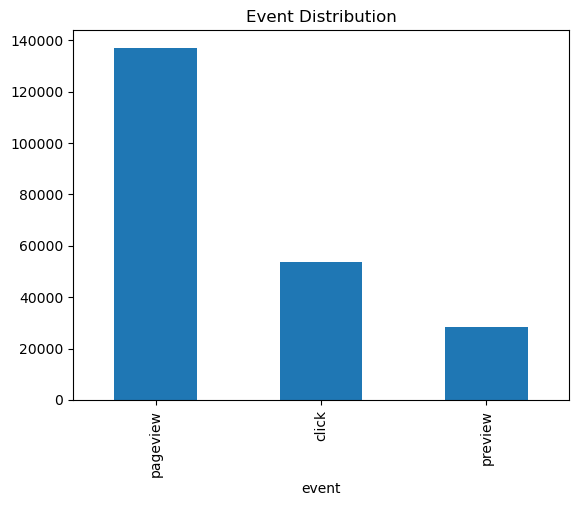

In [14]:
df['event'].value_counts().plot(kind='bar')
plt.title("Event Distribution")
plt.show()

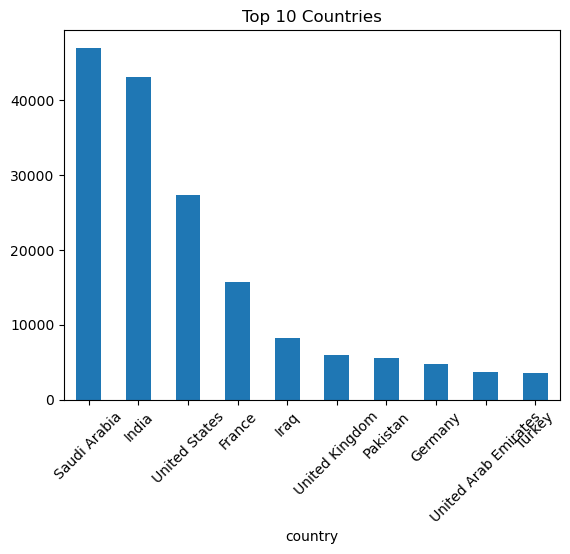

In [16]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Top 10 Countries")
plt.show()

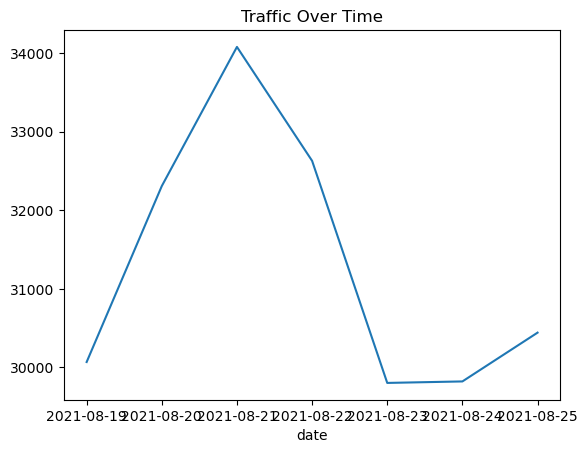

In [19]:
df.groupby(df['date'].dt.date).size().plot()
plt.title("Traffic Over Time")
plt.show()